Conjunto de datos
MTG Dataset.
Carga del dataset
Estructura de los datos,
Variables de entrada
variable objetivo

Separación de datos
Uso de train_test_split
Para qué se separan los datos
Diferencia entre training set y test set

Procesamiento de datos
Tecnicas de procesamiento

Entrenamiento de modelo

Predicciones
Uso de predict()
Explicar como hace predicciones
Ejemplo de predicciones con datos nuevos

Evaluación del modelo
Dos métricas de evaluación
Por clasificación
Por refresión

Visualización e interpretación de resultados

Almenos una visualización
Matriz de confusión
Gráfico de datos
interpretación de resultados

**0. Imports**

In [3]:
from google.colab import files
import pandas as pd
import io

**1. Introducción**  <br>
*   **Qué es Scikit-learn**<br>
*   **Para qué se utiliza** <br>
*  **Tipos de problemas que suele resolver** <br>

**2. Dataset**







**1. Introducción**  <br>
 **Qué es Scikit-learn**<br>
 Es una extensa biblioteca y herramienta computacional dentro del ecosistema cientifico de Python  <br>

 *   **Para qué se utiliza** <br>
 Se utiliza fundamentalmente para construir, entrenar, evaluar y poner en producción modelos de aprendizaje automático (Machine Learning). La herramienta permite crear flujos de trabajo completos que abarcan desde la carga y preparación de los datos hasta la evaluación rigurosa del rendimiento de un modelo computacional.  <br>

 **Tipos de problemas que suele resolver**  <br>



*   Aprendizaje supervisado
  Permite identificar a qué categoría pertenece un conjunto de datos

    * Clasificación: permite identificar a qué categoria pertenece un conjunto de datos (Máquinas de Vectores de Soporte, Naive Bayes...)
    * Regresión: se utiliza para predecir valores continuos o númericos (Regresión Lineal, Procesos Gaussianos...)

  *   Aprendizaje no supervisado <br>
  Sirve para descubrir estructuras, patrones o relaciones ocultas en conjuntos de datos que no tienen etiquetas previas
      * Cluthering: Permite agrupar automáticamente datos que tienen características similares.
      * Reducción de Dimensionalidad: Facilita la visualización y el procesamiento de datos complejos reducioendo la cantidad de variables sin perder mucha información. PCA, t-SNE.
      * Detección de anamolías y novedades: Identifica datos atípicos (outliers) que se desvían de la norma del conjunto de datos.
  *   Transformación y Procesamiento de Datos: resuelve problemas relacionados con la lipieza y adecuación de datos crudos antes de que ingresen a un modelo predictivo
        * Incluye la imputación de valores faltantes, estandarización y normalización de características. Por ejemplo texto o imágenes a datos númericos
      * Encadenar múltiples pasos de transformación utilizando conductos (Pipelines)
*   Selección y evaluación de Modelos: Ofrece herramientas para responder a ¨Qué tan bueno es mi modelo?¨ mediante validación cruzzada y la búsqueda de los hiperparámetros óptimos para maejorar la precision

















**2. Dataset**

In [5]:

# creamos selector de archivos
uploaded = files.upload()

# Obtenemso el nombre del archivo
nombre_archivo = list(uploaded.keys())[0]

# cargamos el contenido a un DataFrame
df = pd.read_json(io.BytesIO(uploaded[nombre_archivo]))

# Output para demostrar que funciona
print("Estructura de los datos cargada:")
print(df.head(3))

Saving mtg.json to mtg.json
Estructura de los datos cargada:
  object                                    id  \
0   card  0000419b-0bba-4488-8f7a-6194544ce91e   
1   card  0000579f-7b35-4ed3-b44c-db2a538066fe   
2   card  00006596-1166-4a79-8443-ca9f82e6db4e   

                              oracle_id multiverse_ids   mtgo_id  arena_id  \
0  b34bb2dc-c1af-4d77-b0b3-a0fb342a5fc6       [668564]  129825.0   91829.0   
1  44623693-51d6-49ad-8cd7-140505caf02f       [109722]   25527.0       NaN   
2  8ae3562f-28b7-4462-96ed-be0cf7052ccc       [189637]   34586.0       NaN   

   tcgplayer_id  cardmarket_id           name lang  ... flavor_name  \
0      558404.0       777725.0         Forest   en  ...         NaN   
1       14240.0        13850.0    Fury Sliver   en  ...         NaN   
2       33347.0        21851.0  Kor Outfitter   en  ...         NaN   

  attraction_lights color_indicator printed_type_line  printed_text  \
0               NaN             NaN               NaN           NaN  

Estructura de los datos.

En Machine Learning, los datos se organizan de forma bidimensional. Nuestro JSON de Scryfall contiene:
Filas: cada fila representa una carga de Magic
Columnas: Cada columna es una característica de la carta: (nombre, coste, texto, etc.)


Features
Las Features son las variables independientes que el modelo analiza para encontrar patrones. En Scikit-learn se representan con $X$ debido a que suele ser una matriz 2D.

Target
El target es la variable dependiente que queremos predecir. En Scikit-learn se representa con $y$ debido a que suele ser un vector 1D.

Dependiendo de que queramos que haga nuestro modelo el target cambiará. En este caso usaremos Regresión para predecir el Precio según las características de la carta

3. Seperación de Datos
Es importante dividir el conjunto de datos original en dos subgrupos independientes. En Scikit-learn se usa *train_test_split*


Si evaluamos el modelo con los mismos datos que usamos para entrenarlo no sabra como se comportará ante datos del ¨mundo real¨ que nunca ha visto. A esto lo llamamos **Overfitting**

Training Set : Es la proporción de datos que se entrega al algoritmo

Test set: Es una porcoón de datos que se mantiene oculta al modelo durante el entrenamiento. Se usa para medir la precisión real del modelo.

In [7]:
# Suponiendo que tu DataFrame se llama 'df'
# Primero seleccionamos las columnas que queremos usar
# Usamos .copy() para evitar avisos de Pandas y .fillna(0) para que no haya errores con Scikit-learn

# Definimos las variables de entrada (X)
X = df[['cmc', 'power', 'toughness']].copy()

# Convertimos power y toughness a números (por si vienen como texto)
X['power'] = pd.to_numeric(X['power'], errors='coerce').fillna(0)
X['toughness'] = pd.to_numeric(X['toughness'], errors='coerce').fillna(0)

# Definimos la variable objetivo (y)
y = df['rarity']

# AHORA ya puedes ejecutar el código de separación:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Éxito. Datos de entrenamiento: {len(X_train)} | Datos de prueba: {len(X_test)}")

Éxito. Datos de entrenamiento: 90096 | Datos de prueba: 22524


In [8]:
from sklearn.model_selection import train_test_split

# Dividimos los datos: 80% para entrenar y 20% para probar
# 'test_size=0.2' define el porcentaje del test set
# 'random_state' asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba: {len(X_test)}")

Muestras de entrenamiento: 90096
Muestras de prueba: 22524


4. Procesamiento de Datos

Ahora que tenemos los datos divididos, debemos explicar que transformaciones aplicamos antess de pasarlos por el modelo. Scikit-learn requiere que todos los datos de entrada sean numéricos y estén limpios.

Técnicas que debemos incluir en nustro Dataset:


*   Data Cleaning <br>
    Muchas cartas no tienen fuerza o resistencia (como las cartas de Conjuro)
*   Label Encoding <br>
  variable objetivo. Precio.

*   Feature Scaling <br>
  Modificar el rango de las variables para que coincidan entre los diferentes tipos
  



In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- 1. DATA CLEANING (Limpieza de nulos y tipos) ---
# Creamos una copia para no alterar el dataframe original
X = df[['cmc', 'power', 'toughness']].copy()

# Convertimos power y toughness a números.
# 'errors=coerce' convierte valores como "*" o "1+*" en NaN (nulo)
X['power'] = pd.to_numeric(X['power'], errors='coerce')
X['toughness'] = pd.to_numeric(X['toughness'], errors='coerce')

# Rellenamos los nulos (cartas de conjuro, artefactos, etc.) con 0
X = X.fillna(0)

# --- 2. TRATAMIENTO DE LA VARIABLE OBJETIVO (Precio) ---
# El precio suele venir como string en el JSON. Lo convertimos a float.
# Nota: Si usas el campo 'prices', recuerda extraer 'usd'.
y = pd.to_numeric(df['prices'].apply(lambda x: x.get('usd') if isinstance(x, dict) else None), errors='coerce')

# Eliminamos las filas donde el precio es desconocido (no podemos entrenar sin saber la respuesta)
indices_validos = y.dropna().index
X = X.loc[indices_validos]
y = y.dropna()

# (Aquí vendría tu train_test_split que ya tienes hecho)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. FEATURE SCALING (Escalado de variables) ---
scaler = StandardScaler()

# Ajustamos el escalador con los datos de entrenamiento y transformamos ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Procesamiento completado.")

# 1. Verificar que no que no den nulos
print(f"Nulos en X_train: {pd.DataFrame(X_train_scaled).isnull().sum().sum()}")

# 2. Verificar el rango del escalado (debería estar cerca de media 0 y desviación 1)
print(f"Media de la primera columna escalada: {X_train_scaled[:,0].mean():.2f}")

# 3. Verificar que y (precio) sea numérico
print(f"Tipo de dato de y: {y.dtype}")

Procesamiento completado.
Nulos en X_train: 0
Media de la primera columna escalada: -0.00
Tipo de dato de y: float64


5. Entrenamiento del Modelo
Para predecir el precio utilizaremos el algoritmo Random Forest Regressor. Usa relaciones no lineales: esto nos ayudará a predecir que una "Mitica" de coste 0 puede valer más que una "Común" de coste 10


In [11]:
from sklearn.ensemble import RandomForestRegressor

# 1. Instanciar el modelo (creamos el "bosque" de 100 árboles)
modelo_mtg = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenamiento (Fit)
# Usamos los datos escalados y la variable objetivo (precio)
modelo_mtg.fit(X_train_scaled, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


6. Prediccciones
Ahora que tenemos 90.096 cartas de entrenamiento miraremos que tal funciona con las otras 22.524

In [12]:
# Realizamos las predicciones sobre el set de prueba
y_pred = modelo_mtg.predict(X_test_scaled)

# Mostramos una comparativa de los primeros 5 resultados
print("Comparativa: Precio Real vs. Predicción")
for i in range(5):
    print(f"Real: ${y_test.iloc[i]:.2f} ---> Predicho: ${y_pred[i]:.2f}")

Comparativa: Precio Real vs. Predicción
Real: $0.14 ---> Predicho: $3.63
Real: $14.70 ---> Predicho: $3.00
Real: $0.47 ---> Predicho: $4.28
Real: $2.32 ---> Predicho: $19.43
Real: $3.70 ---> Predicho: $1.44


7. Evaluación del Modelo
En el caso de la predicción de precios es mejor usar medidas de distancia de error más que acierto/error


*   MAE (Error Absolutio Medio): Indica en promedio por cuantos dólares se equivoca el modelo
*   $R^2$ Indica como de bien se ajusto el modelo a los datos siendo 1.0 perfecto.



In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} USD")
print(f"Coeficiente R^2: {r2:.2f}")

Error Absoluto Medio (MAE): 7.27 USD
Coeficiente R^2: 0.00


8. Visualización de Resultados
Usaremos un Gráfico de Dispersión "Scatter Plot" que compara los precios reales frente a los predichos

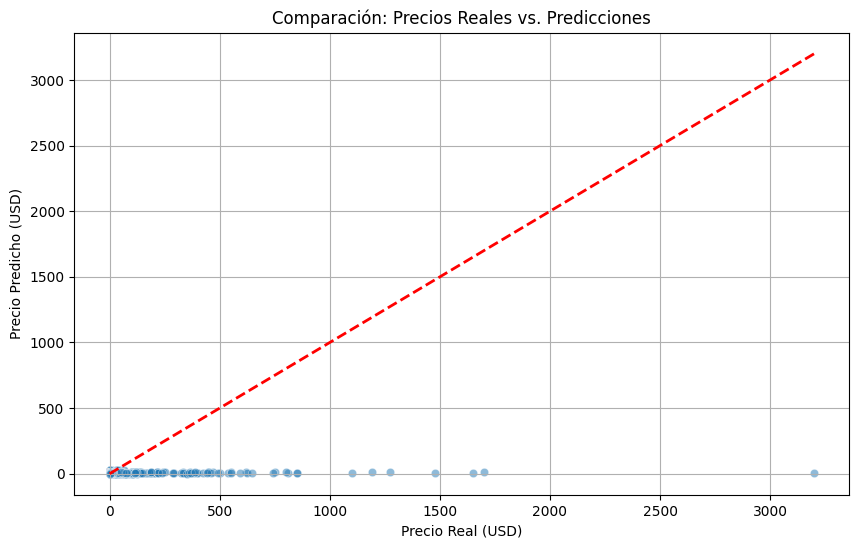

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Creamos el gráfico de dispersión
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# Añadimos una línea ideal (donde Real == Predicho)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)

plt.title('Comparación: Precios Reales vs. Predicciones')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.grid(True)
plt.show()

Bibliografía


*   User Guide. (s. f.). Scikit-learn. https://scikit-learn.org/stable/user_guide.html
*   Fundamentos de Machine Learning. Scikit-learn. https://scikit-learn.org/stable/glossary.html
*   Preprocessing data. Learning Scikit-learn. https://scikit-learn.org/stable/glossary.html
*   Random Forest Regressor. Scikit-learn Documentation. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
*   Intro to Data Structures. Pandas. https://pandas.pydata.org/docs/user_guide/dsintro.html
*   Filling missing values. Pandas. https://pandas.pydata.org/docs/user_guide/missing_data.html
*   Dataset - Scryfall API Documentation: Card Objects. https://scryfall.com/docs/api/bulk-data









